<a href="https://colab.research.google.com/github/KADA-SEDODE/Predict-Customer-Churn-with-TensorFlow/blob/main/Deep_learning_Tensorflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importation des données

In [59]:
# Importer les bibliothèques nécessaires
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, TensorBoard
import datetime
import os

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [60]:
# Charger le jeu de données à partir d'un fichier CSV
df = pd.read_csv('/content/drive/MyDrive/données/Churn.csv')
df

,Customer ID,Gender,Senior Citizen,Partner,Dependents,tenure,Phone Service,Multiple Lines,Internet Service,Online Security,...,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn
0,7590-VHVEA,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
2,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
3,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
4,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7039,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7040,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7041,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7042,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [61]:
print(df.columns)
print(df["Churn"].unique())

Index(['Customer ID', 'Gender', 'Senior Citizen', 'Partner', 'Dependents',
       'tenure', 'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn'],
      dtype='object')
['No' 'Yes']


Convertit des variables catégorielles en variables indicatrices/dummies

In [62]:
# Séparer les caractéristiques (X) et la variable cible (y)
X = pd.get_dummies(df.drop(['Churn', 'Customer ID'], axis=1)) # suppression et encodage  ensemble
y = df['Churn'].apply(lambda x: 1 if x=='Yes' else 0)

# Description des données

In [63]:
df.describe(include="all")

,Customer ID,Gender,Senior Citizen,Partner,Dependents,tenure,Phone Service,Multiple Lines,Internet Service,Online Security,...,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn
count,7044,7044,7044.000000,7044,7044,7044.000000,7044,7044,7044,7044,...,7044,7044,7044,7044,7044,7044,7044,7044.000000,7044,7044
unique,7044,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,3186-AJIEK,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,,No
freq,1,3555,NaN,3641,4934,NaN,6361,3390,3096,3499,...,3096,3474,2811,2786,3876,4172,2366,NaN,11,5175
mean,NaN,NaN,0.162124,NaN,NaN,32.366695,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.756736,NaN,NaN
std,NaN,NaN,0.368590,NaN,NaN,24.560582,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090786,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7044 entries, 0 to 7043
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Customer ID        7044 non-null   object 
 1   Gender             7044 non-null   object 
 2   Senior Citizen     7044 non-null   int64  
 3   Partner            7044 non-null   object 
 4   Dependents         7044 non-null   object 
 5   tenure             7044 non-null   int64  
 6   Phone Service      7044 non-null   object 
 7   Multiple Lines     7044 non-null   object 
 8   Internet Service   7044 non-null   object 
 9   Online Security    7044 non-null   object 
 10  Online Backup      7044 non-null   object 
 11  Device Protection  7044 non-null   object 
 12  Tech Support       7044 non-null   object 
 13  Streaming TV       7044 non-null   object 
 14  Streaming Movies   7044 non-null   object 
 15  Contract           7044 non-null   object 
 16  Paperless Billing  7044 

Pas de  données qui manquent

#  Diviser les données en ensembles d'entraînement et de test

In [64]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2,random_state=97)

# Afficher les premières lignes de la variable cible d'entraînement
y_train.head()


,Churn
2049,1
4753,0
2581,0
5311,0
2089,0


In [65]:
# Normalisation des variables continues
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Deeplearning avec tensorflow

In [68]:
# Construction du modèle
model = Sequential([
    Dense(64, activation='relu', input_dim=X_train.shape[1]), # indique le nombre de variables d’entrée
    Dropout(0.3),
    Dense(32, activation='relu'), # Deuxième couche cachée, 32 neurones
    Dense(1, activation='sigmoid') # Couche de sortie
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [69]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [70]:
# Callbacks (arrêt anticipé + suivi TensorBoard)
log_dir = os.path.join("logs", datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
tensorboard_cb = TensorBoard(log_dir=log_dir, histogram_freq=1)
early_stop_cb = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)


In [72]:
# Entraînement du modèle
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop_cb, tensorboard_cb],
    verbose=1
)

Epoch 1/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.6226 - loss: 0.7198 - val_accuracy: 0.7666 - val_loss: 0.4600
Epoch 2/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8928 - loss: 0.2842 - val_accuracy: 0.7649 - val_loss: 0.4864
Epoch 3/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9617 - loss: 0.1145 - val_accuracy: 0.7587 - val_loss: 0.5398
Epoch 4/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9814 - loss: 0.0568 - val_accuracy: 0.7524 - val_loss: 0.6012
Epoch 5/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9820 - loss: 0.0410 - val_accuracy: 0.7427 - val_loss: 0.6587
Epoch 6/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9825 - loss: 0.0434 - val_accuracy: 0.7391 - val_loss: 0.7143
Epoch 7/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9866 - loss: 0.0299 - val_accuracy: 0.7285 - val_loss: 0.7785
Epoch 8/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9868 - loss: 0.0285 - 

In [74]:
# Évaluation du modèle
y_pred = (model.predict(X_test) > 0.5).astype(int) # le seuil de décision pour transformer la proba en prédiction finale.
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Sauvegarde du modèle
# model.save("model_churn_tf")

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Accuracy: 0.7601135557132718
              precision    recall  f1-score   support

           0       0.76      0.98      0.86      1024
           1       0.75      0.18      0.29       385

    accuracy                           0.76      1409
   macro avg       0.76      0.58      0.57      1409
weighted avg       0.76      0.76      0.70      1409



Le modèle prédit très bien les clients fidèles (98 % de rappel).

Le modèle rate beaucoup de vrais churns (rappel = 0.18). Il a du mal à détecter les départs clients.

Cause : Déséquilibre des classes

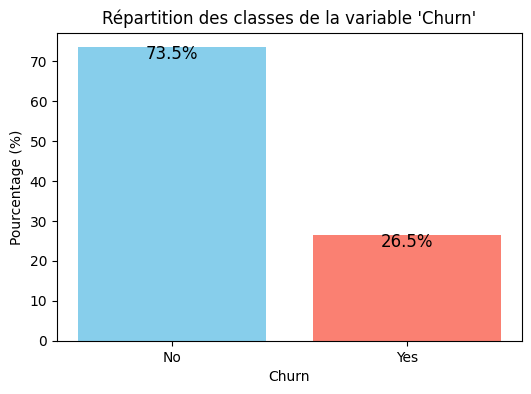

In [79]:
churn_counts = df['Churn'].value_counts()
churn_percent = df['Churn'].value_counts(normalize=True) * 100

plt.figure(figsize=(6,4))
bars = plt.bar(churn_counts.index, churn_percent, color=['skyblue', 'salmon'])
plt.title("Répartition des classes de la variable 'Churn'")
plt.ylabel("Pourcentage (%)")
plt.xlabel("Churn")
for bar, pct in zip(bars, churn_percent):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 3,
             f'{pct:.1f}%', ha='center', color='black', fontsize=12)
plt.show()


In [76]:
model.save("model_churn_tf.keras")  # POUR sauvegarder
model_loaded = load_model("model_churn_tf.keras")  # pour charger le modele
model.export("model_churn_tf_serving")  # sauvegarder pour le déploiement (TensorFlow Serving / TFX)

Sequential est utile pour empiler des couches, chaque couche possédant un tenseur d'entrée et un tenseur de sortie. Les couches sont des fonctions dont la structure mathématique est connue, réutilisable et dont les variables sont apprenables. La plupart des modèles TensorFlow sont composés de couches.

La fonction de perte prend un vecteur de valeurs de vérité terrain et un vecteur de logits et renvoie une perte scalaire pour chaque exemple. Cette perte est égale à la probabilité logarithmique négative de la classe vraie : la perte est nulle si le modèle est certain de la classe correcte.

A faire : Ponderer la classe la moin represneter pour  ameliorer le modèle ;